# Notebook 02: Análisis Exploratorio de Datos (EDA)
**Proyecto:** Emisiones atmosféricas de fuentes difusas en Chile (2019-2024)

Continuando con el trabajo del Notebook 1 (donde consolidamos y redujimos los datos a la zona centro-sur), el objetivo de este cuaderno es explorar el comportamiento estadístico de las emisiones. 

Realizaremos un análisis enfocado principalmente en el Material Particulado 2,5 (MP2,5) para descubrir patrones geográficos y temporales antes de llevar estos datos a nuestra aplicación en Streamlit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga de Datos Pre-procesados
Cargamos el dataset de 53.440 registros generado en el cuaderno anterior.

In [2]:
# Ruta del archivo procesado en el Notebook 1
ruta_datos = "../data/processed/emisiones_centro_sur_2019_2024.csv"
df = pd.read_csv(ruta_datos)

print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (53440, 9)


,año,region,provincia,comuna,id_comuna,tipo_fuente,contaminantes,rural_o_urbano,cantidad_toneladas
0,2019,Araucanía,Cautín,Carahue,9102,Combustión de Leña Residencial Urbana,Carbono Negro,NaN,44.789389
1,2019,Araucanía,Cautín,Carahue,9102,Combustión de Leña Residencial Urbana,Compuestos Orgánicos Volátiles,NaN,5290.085541
2,2019,Araucanía,Cautín,Carahue,9102,Combustión de Leña Residencial Urbana,Dióxido de azufre (SO2),NaN,2.752523
3,2019,Araucanía,Cautín,Carahue,9102,Combustión de Leña Residencial Urbana,Dióxido de carbono (CO2),NaN,45730.802934
4,2019,Araucanía,Cautín,Carahue,9102,Combustión de Leña Residencial Urbana,MP10,NaN,460.803866


## 2. Estandarización Final de Categorías
Antes de graficar, ajustaremos la nomenclatura de las fuentes de leña. Como descubrimos en la exploración inicial, los nombres originales son muy largos o inconsistentes en mayúsculas/minúsculas.

In [3]:
# Estandarizamos los nombres para los gráficos y el dashboard
df["tipo_fuente"] = df["tipo_fuente"].replace({
    "Combustión de Leña Residencial Urbana": "Leña residencial urbana",
    "Combustión de leña Rural Urbana": "Leña residencial rural",
})

print("Categorías estandarizadas:")
print(df["tipo_fuente"].value_counts())

Categorías estandarizadas:
tipo_fuente
Leña residencial rural     11376
Leña residencial urbana    11136
Incendios Forestales       11002
Quemas Agrícolas           10496
Incendios Urbanos           9430
Name: count, dtype: int64


## 3. Aislamiento del Contaminante Objetivo (MP2,5)
El dataset contiene múltiples contaminantes (MP10, CO, NOx, etc.). Sumar toneladas de contaminantes distintos carece de sentido físico. Para el análisis visual de este EDA, filtraremos exclusivamente el **MP2,5**, que es el principal indicador de riesgo respiratorio en la zona sur.

In [4]:
df_mp25 = df[df["contaminantes"] == "MP2,5"].copy()
print(f"Registros de MP2,5 para analizar: {len(df_mp25)}")

Registros de MP2,5 para analizar: 4624


## 4. Análisis Univariado: Distribución de Toneladas
Analizamos la variable objetivo (`cantidad_toneladas`) para entender cómo se distribuyen las emisiones por cada registro (Comuna x Año x Fuente).

count     4624.000000
mean       222.533120
std       1106.922688
min          0.000085
25%          2.732580
50%         30.971547
75%        207.348358
max      62201.871222
Name: cantidad_toneladas, dtype: float64

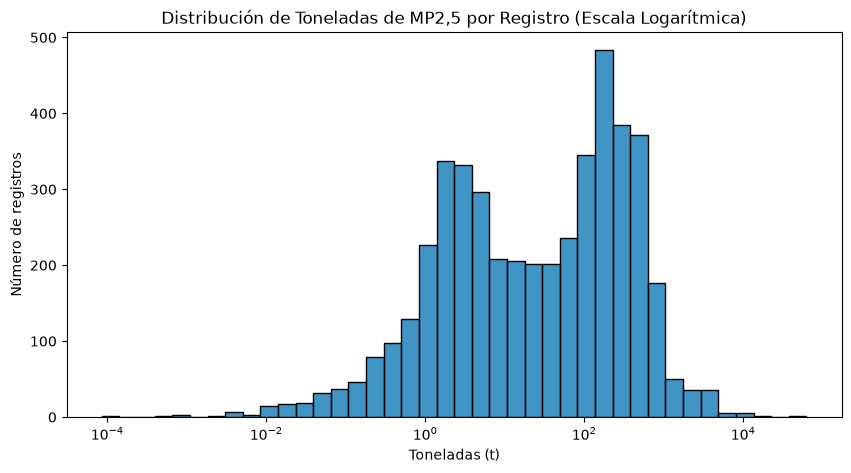

In [5]:
# Estadísticas descriptivas
display(df_mp25["cantidad_toneladas"].describe())

# Histograma en escala logarítmica (excluyendo los 0 para evitar errores matemáticos)
df_positivo = df_mp25[df_mp25["cantidad_toneladas"] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(data=df_positivo, x="cantidad_toneladas", bins=40, log_scale=True, color="#0072B2")
plt.title("Distribución de Toneladas de MP2,5 por Registro (Escala Logarítmica)")
plt.xlabel("Toneladas (t)")
plt.ylabel("Número de registros")
plt.show()

**Interpretación:**
La estadística descriptiva muestra una asimetría extrema (sesgo positivo): la media es muchísimo más alta que la mediana, y el 75% de los datos está por debajo de las 45 toneladas, pero el valor máximo supera las 23.000 toneladas. 
El histograma en escala logarítmica confirma que existen muchos registros pequeños y un grupo reducido de registros masivos (outliers). Estos valores atípicos son fundamentales y representan megaincendios o picos severos de contaminación en grandes ciudades, por lo que no se deben eliminar.

## 5. Análisis Bivariado: Carga Contaminante por Fuente
¿Qué tipo de fuente emite la mayor cantidad de toneladas acumuladas de MP2,5?

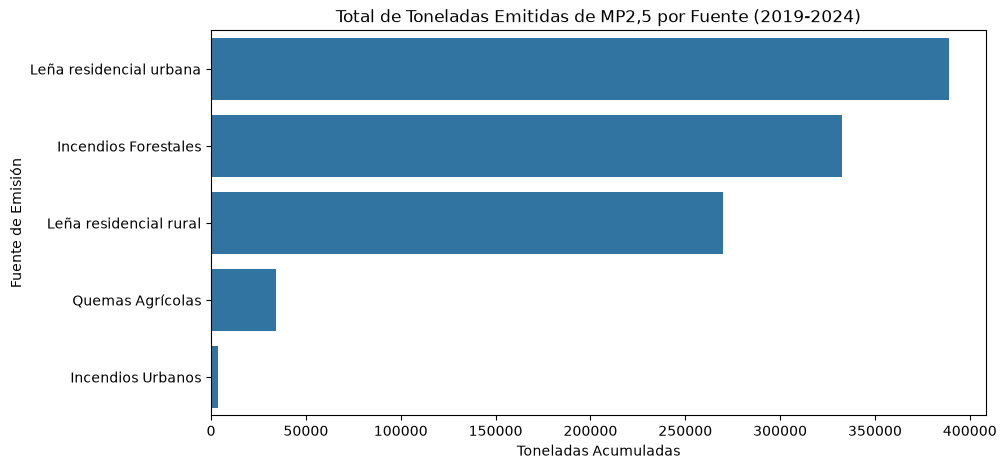

In [8]:
# Agrupamos sumando el total de toneladas por fuente
fuentes_mp25 = df_mp25.groupby("tipo_fuente", as_index=False)["cantidad_toneladas"].sum()
fuentes_mp25 = fuentes_mp25.sort_values("cantidad_toneladas", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fuentes_mp25, x="cantidad_toneladas", y="tipo_fuente")
plt.title("Total de Toneladas Emitidas de MP2,5 por Fuente (2019-2024)")
plt.xlabel("Toneladas Acumuladas")
plt.ylabel("Fuente de Emisión")
plt.show()

**Interpretación:**
Se observa un dominio absoluto de la **Leña Residencial Urbana**, seguida por los **Incendios Forestales**. Las quemas agrícolas e incendios urbanos tienen un impacto casi marginal en el volumen total del MP2,5. Esto nos indica que el problema de la zona centro-sur se divide entre contaminación estructural de las ciudades (leña) y contaminación rural esporádica (incendios).

## 6. Análisis Multivariado: Composición Regional y Temporal
Cruzaremos múltiples variables para entender dónde y cuándo ocurren las mayores emisiones.

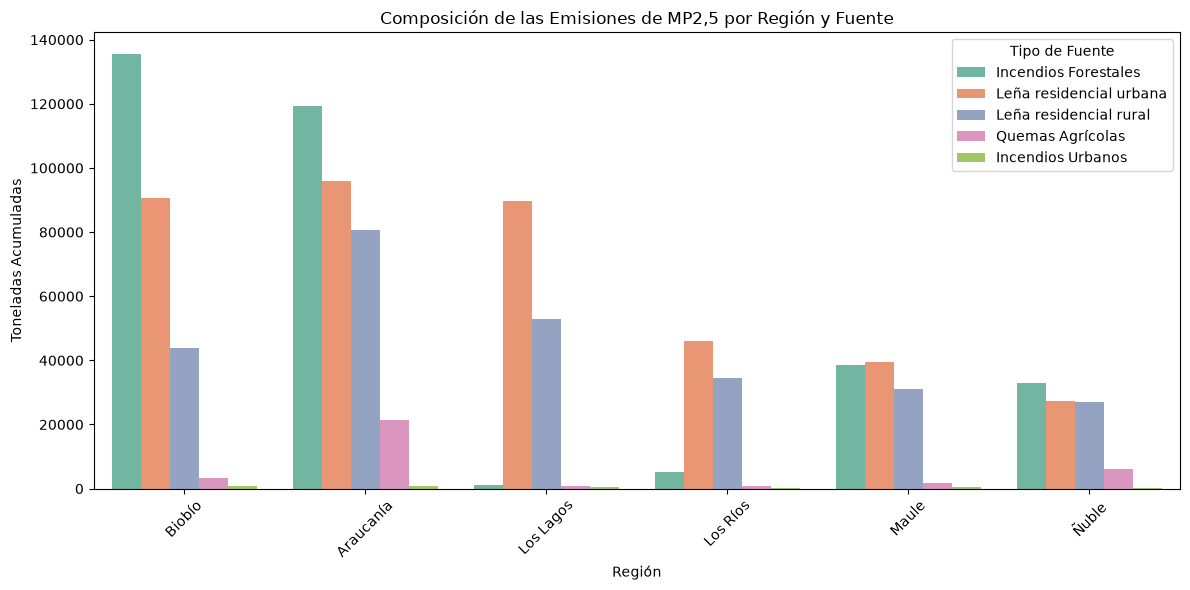

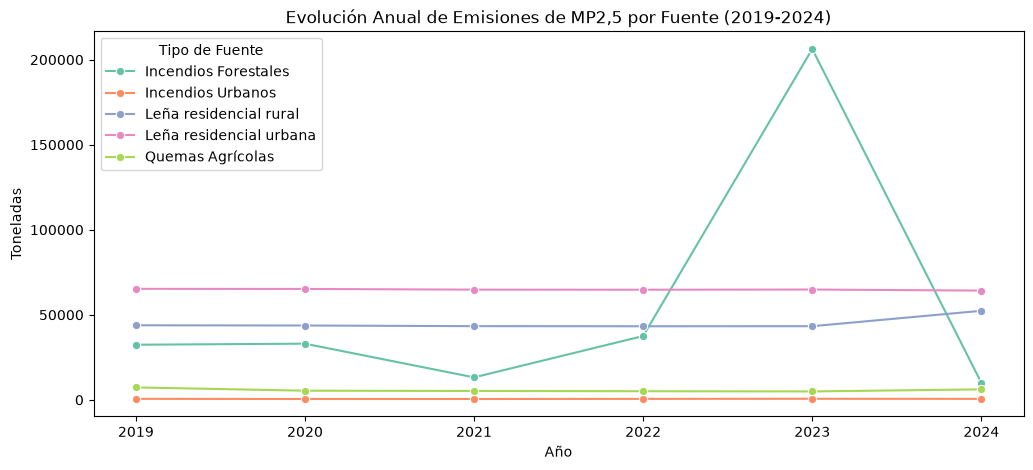

In [9]:
# Gráfico 1: Región vs Toneladas vs Fuente
region_fuente = df_mp25.groupby(["region", "tipo_fuente"], as_index=False)["cantidad_toneladas"].sum()
region_fuente = region_fuente.sort_values("cantidad_toneladas", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_fuente, x="region", y="cantidad_toneladas", hue="tipo_fuente", palette="Set2")
plt.title("Composición de las Emisiones de MP2,5 por Región y Fuente")
plt.xlabel("Región")
plt.ylabel("Toneladas Acumuladas")
plt.xticks(rotation=45)
plt.legend(title="Tipo de Fuente")
plt.tight_layout()
plt.show()

# Gráfico 2: Evolución Anual
evolucion = df_mp25.groupby(["año", "tipo_fuente"], as_index=False)["cantidad_toneladas"].sum()

plt.figure(figsize=(12, 5))
sns.lineplot(data=evolucion, x="año", y="cantidad_toneladas", hue="tipo_fuente", marker="o", palette="Set2")
plt.title("Evolución Anual de Emisiones de MP2,5 por Fuente (2019-2024)")
plt.xlabel("Año")
plt.ylabel("Toneladas")
plt.legend(title="Tipo de Fuente")
plt.show()

**Interpretación Multivariada:**
1. **Dimensión Espacial:** Existe una fuerte asimetría espacial. La Región de La Araucanía lidera las emisiones, impulsada casi enteramente por leña urbana. El Biobío presenta la mayor carga por incendios forestales.
2. **Dimensión Temporal:** La leña residencial muestra una tendencia plana y estructural a lo largo de los 6 años. Por el contrario, los Incendios Forestales son episódicos, mostrando un pico extremo y anormal en el año 2023.